### Extracting JSON Structure

In [16]:
import json
import pyarrow.parquet as pq
from collections import Counter

path = "./data/topic_data/test.parquet"
sample_size = 200

table = pq.read_table(path)
schema = table.schema

def try_parse_json_string(x):
  if not isinstance(x, str):
    return x
  s = x.strip()
  if not s or s[0] not in "{[":
    return x
  try:
    return json.loads(s)
  except Exception:
    return x

def infer_structure(value):
  value = try_parse_json_string(value)

  if value is None:
    return {"type": "null"}

  if isinstance(value, dict):
    return {
      "type": "object",
      "fields": {k: infer_structure(v) for k, v in value.items()}
    }

  if isinstance(value, list):
    if not value:
      return {"type": "array", "items": {"type": "unknown"}}
    item_structs = [infer_structure(v) for v in value[:20]]
    merged = item_structs[0]
    for s in item_structs[1:]:
      merged = merge_structures(merged, s)
    return {"type": "array", "items": merged}

  t = type(value).__name__
  if t == "bool":
    t = "boolean"
  elif t in ("int",):
    t = "integer"
  elif t in ("float",):
    t = "number"
  elif t in ("str",):
    t = "string"
  return {"type": t}

def merge_structures(a, b):
  if a == b:
    return a

  if a.get("type") == "null":
    return b
  if b.get("type") == "null":
    return a

  if a.get("type") == "object" and b.get("type") == "object":
    keys = set(a.get("fields", {}).keys()) | set(b.get("fields", {}).keys())
    fields = {}
    for k in keys:
      av = a.get("fields", {}).get(k, {"type": "null"})
      bv = b.get("fields", {}).get(k, {"type": "null"})
      fields[k] = merge_structures(av, bv)
    return {"type": "object", "fields": fields}

  if a.get("type") == "array" and b.get("type") == "array":
    return {"type": "array", "items": merge_structures(a.get("items", {}), b.get("items", {}))}

  # union type
  a_types = set(a["type"] if isinstance(a["type"], list) else [a["type"]])
  b_types = set(b["type"] if isinstance(b["type"], list) else [b["type"]])
  return {"type": sorted(a_types | b_types)}

summary = {}

for i, field in enumerate(schema):
  col_name = field.name
  arr = table.column(i)
  values = arr.to_pylist()[:sample_size]

  non_null_values = [v for v in values if v is not None]
  null_count = len(values) - len(non_null_values)

  if non_null_values:
    inferred = infer_structure(non_null_values[0])
    for v in non_null_values[1:]:
      inferred = merge_structures(inferred, infer_structure(v))
  else:
    inferred = {"type": "null"}

  summary[col_name] = {
    "parquet_type": str(field.type),
    "nullable": field.nullable,
    "sampled_rows": len(values),
    "sample_nulls": null_count,
    "inferred_structure": inferred,
  }

print("Parquet schema:")
print(schema)
print("\nNested JSON structure summary by column:")
print(json.dumps(summary, indent=2, ensure_ascii=False))

Parquet schema:
index: int32
find_cite: struct<top_references: struct<title: list<element: string>, paper_local_path: list<element: string>> (... 1 chars omitted)
  child 0, top_references: struct<title: list<element: string>, paper_local_path: list<element: string>>
      child 0, title: list<element: string>
          child 0, element: string
      child 1, paper_local_path: list<element: string>
          child 0, element: string
summary: struct<topic: string, revised_topic: string, motivation: string, method: struct<targeted_designs_sum (... 312 chars omitted)
  child 0, topic: string
  child 1, revised_topic: string
  child 2, motivation: string
  child 3, method: struct<targeted_designs_summary: string, targeted_designs_details: struct<design_name: list<element: (... 121 chars omitted)
      child 0, targeted_designs_summary: string
      child 1, targeted_designs_details: struct<design_name: list<element: string>, description: list<element: string>, problems_solved: list (... 18

### Subsample

In [17]:
import random
import pyarrow as pa

subset_size = min(600, table.num_rows)
rng = random.Random(42)

sample_indices = sorted(rng.sample(range(table.num_rows), subset_size))
subset_table = table.take(pa.array(sample_indices))

values = subset_table.column("target_paper").to_pylist()  # overwrite with sampled paper titles
sample_size = subset_size  # keep this aligned with your sampled subset size

print(f"Sampled {subset_size} papers from {table.num_rows} total rows.")
print("First 5 sampled papers:")
print(values[:5])

Sampled 600 papers from 3495 total rows.
First 5 sampled papers:
['LiveHPS LiDAR based Scene level Human Pose and Shape Estimation in Free Environment', 'Logit Standardization in Knowledge Distillation', 'Koala Key Frame Conditioned Long Video LLM', 'AV2AV Direct Audio Visual Speech to Audio Visual Speech Translation with Unified Audio Visual Speech Representation', 'Rapid 3D Model Generation with Intuitive 3D Input']


### Publishing Date scraping

In [18]:
import os
import re
import time
import requests
import pyarrow as pa

API_KEY = os.getenv("SEMANTIC_SCHOLAR_API_KEY")  # optional
MATCH_URL = "https://api.semanticscholar.org/graph/v1/paper/search/match"
HEADERS = {"x-api-key": API_KEY} if API_KEY else {}

session = requests.Session()
session.headers.update(HEADERS)

def _norm_title(t):
  return re.sub(r"[^a-z0-9]+", "", t.lower()) if isinstance(t, str) else ""

def fetch_publication_date(title, max_retries=5):
  if not title:
    return None

  params = {
    "query": title,
    "fields": "title,year,publicationDate"
  }

  for attempt in range(max_retries):
    try:
      r = session.get(MATCH_URL, params=params, timeout=20)
      if r.status_code == 429:
        time.sleep(min(2 ** attempt, 20))
        continue
      r.raise_for_status()
      payload = r.json()

      # /match can return either a paper object or {"data":[...]}
      if isinstance(payload, dict) and "data" in payload:
        candidates = payload.get("data", [])
        paper = candidates[0] if candidates else {}
      else:
        paper = payload if isinstance(payload, dict) else {}

      if not paper:
        return None

      # prefer exact-ish title match when possible
      qn = _norm_title(title)
      pn = _norm_title(paper.get("title", ""))
      if qn and pn and qn not in pn and pn not in qn:
        # still return if date exists; better than empty
        pass

      return paper.get("publicationDate") or (str(paper["year"]) if paper.get("year") else None)

    except requests.RequestException:
      time.sleep(min(2 ** attempt, 20))

  return None

publish_dates = []
for i, t in enumerate(values, start=1):
  publish_dates.append(fetch_publication_date(t))
  if i % 25 == 0:
    print(f"Processed {i}/{len(values)}")
  time.sleep(0.12)  # be polite to API

# add/replace column in subset_table
if "publish_date" in subset_table.column_names:
  col_idx = subset_table.column_names.index("publish_date")
  subset_table = subset_table.set_column(col_idx, "publish_date", pa.array(publish_dates, type=pa.string()))
else:
  subset_table = subset_table.append_column("publish_date", pa.array(publish_dates, type=pa.string()))

print("Done. Added 'publish_date' column to subset_table.")
print("Sample:", list(zip(values[:5], publish_dates[:5])))

Processed 25/600
Processed 50/600
Processed 75/600
Processed 100/600
Processed 125/600
Processed 150/600
Processed 175/600
Processed 200/600
Processed 225/600
Processed 250/600
Processed 275/600
Processed 300/600
Processed 325/600
Processed 350/600
Processed 375/600
Processed 400/600
Processed 425/600
Processed 450/600
Processed 475/600
Processed 500/600
Processed 525/600
Processed 550/600
Processed 575/600
Processed 600/600
Done. Added 'publish_date' column to subset_table.
Sample: [('LiveHPS LiDAR based Scene level Human Pose and Shape Estimation in Free Environment', '2024-02-27'), ('Logit Standardization in Knowledge Distillation', '2024-03-03'), ('Koala Key Frame Conditioned Long Video LLM', '2024-04-05'), ('AV2AV Direct Audio Visual Speech to Audio Visual Speech Translation with Unified Audio Visual Speech Representation', '2023-12-05'), ('Rapid 3D Model Generation with Intuitive 3D Input', '2024-06-16')]


In [19]:
# Save sampled table (including publish_date) for faster reuse
output_path = "./data/topic_data/subset_with_publish_date.parquet"

if "publish_date" not in subset_table.column_names:
  raise ValueError("subset_table does not contain 'publish_date' yet.")

os.makedirs(os.path.dirname(output_path), exist_ok=True)
pq.write_table(subset_table, output_path, compression="zstd")

print(f"Saved {subset_table.num_rows} rows to: {output_path}")
print("Columns:", subset_table.column_names)

Saved 600 rows to: ./data/topic_data/subset_with_publish_date.parquet
Columns: ['index', 'find_cite', 'summary', 'target_paper', 'publish_date']


In [20]:
# input_path = "./data/topic_data/subset_with_publish_date.parquet"

# subset_table = pq.read_table(input_path)
# values = subset_table.column("target_paper").to_pylist()

# print(f"Loaded {subset_table.num_rows} rows from: {input_path}")
# print("Columns:", subset_table.column_names)
# print("First 5 target_paper values:", values[:5])

### Calculate Novelty Score

In [31]:
from datetime import date, datetime, timedelta

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

from NoveltyAssessment.novelty_scorer import (
    DEFAULT_CITATION_PROXY,
    REFERENCE_DATE,
    normalize_paper_record,
)

print(REFERENCE_DATE)
def _parse_publish_date(value):
    """Parse publish date strings like YYYY or YYYY-MM-DD into a date object."""
    if value is None:
        return None

    if isinstance(value, datetime):
        return value.date()

    if isinstance(value, date):
        return value

    text = str(value).strip()
    if not text:
        return None

    # Try common full-date formats first.
    for fmt in ("%Y-%m-%d", "%Y/%m/%d", "%Y-%m", "%Y/%m"):
        try:
            parsed = datetime.strptime(text, fmt)
            return parsed.date().replace(day=1)
        except ValueError:
            pass

    # Fallback: year-only values.
    if text[:4].isdigit():
        return date(int(text[:4]), 1, 1)

    return None


def _row_to_scoring_paper(row, idx):
    """Convert a subset_table row to a normalized paper record."""
    normalized = normalize_paper_record(row)

    publish_dt = _parse_publish_date(row.get("publish_date"))
    year = normalized.get("year")
    if year is None and publish_dt is not None:
        year = publish_dt.year

    title = normalized.get("title", "").strip()
    abstract = normalized.get("abstract", "").strip()
    idea_text = f"{title}. {abstract}" if abstract else title

    return {
        "paperId": normalized.get("paperId") or f"subset_{idx}",
        "title": title,
        "abstract": abstract,
        "idea_text": idea_text,
        "year": year,
        "citationCount": normalized.get("citationCount"),
        "publish_date": publish_dt,
        "raw": row,
    }


def _safe_float(value):
    try:
        return float(value) if value is not None else None
    except (TypeError, ValueError):
        return None


def _split_historical_contemporary(pool_indices, papers):
    historical_idx = []
    contemporary_idx = []

    for idx in pool_indices:
        year = papers[idx].get("year")
        try:
            year = int(year)
            paper_date = datetime(year, 1, 1)
            if paper_date < REFERENCE_DATE:
                historical_idx.append(idx)
            else:
                contemporary_idx.append(idx)
        except (TypeError, ValueError):
            # Keep behavior aligned with novelty_scorer: invalid/missing year -> contemporary
            contemporary_idx.append(idx)

    return historical_idx, contemporary_idx


def _mean_distance(target_embedding, candidate_embeddings):
    if candidate_embeddings.size == 0:
        return 0.0

    return float(
        cosine_distances(target_embedding.reshape(1, -1), candidate_embeddings)[0].mean()
    )


def _compute_pool_score(target_idx, pool_indices, papers, paper_embeddings):
    historical_idx, contemporary_idx = _split_historical_contemporary(pool_indices, papers)

    target_embedding = paper_embeddings[target_idx]

    historical_embeddings = (
        paper_embeddings[historical_idx] if historical_idx else np.empty((0, paper_embeddings.shape[1]))
    )
    contemporary_embeddings = (
        paper_embeddings[contemporary_idx] if contemporary_idx else np.empty((0, paper_embeddings.shape[1]))
    )

    hd_ideas = _mean_distance(target_embedding, historical_embeddings)
    cd_ideas = _mean_distance(target_embedding, contemporary_embeddings)

    contemporary_citations = [
        c
        for c in (_safe_float(papers[idx].get("citationCount")) for idx in contemporary_idx)
        if c is not None
    ]

    if contemporary_citations:
        cc = float(np.mean(contemporary_citations))
        citation_proxy_used = False
    else:
        cc = DEFAULT_CITATION_PROXY
        citation_proxy_used = True

    denominator = 1 + hd_ideas
    numerator = (1 + cd_ideas) * cc
    novelty_score = numerator / denominator if denominator > 0 else 0.0

    return {
        "novelty_score": float(novelty_score),
        "historical_distance": float(hd_ideas),
        "contemporary_distance": float(cd_ideas),
        "contemporary_citations": float(cc),
        "citation_proxy_used": citation_proxy_used,
        "num_historical_papers": len(historical_idx),
        "num_contemporary_papers": len(contemporary_idx),
        "reference_date": REFERENCE_DATE.isoformat(),
    }


def compute_subset_novelty_twice(subset_table, embedding_model="all-MiniLM-L6-v2"):
    """
    Compute novelty score for each target paper in two modes using one shared embedding matrix:
    1) against all subset papers
    2) against only papers published >=1 year before the target paper
    """
    rows = subset_table.to_pylist()
    papers = [_row_to_scoring_paper(row, i) for i, row in enumerate(rows)]

    if not papers:
        return pd.DataFrame()

    # Load/download the model once and embed all papers once.
    model = SentenceTransformer(embedding_model)
    paper_texts = [p["idea_text"] for p in papers]
    paper_embeddings = model.encode(
        paper_texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
    )

    all_indices = list(range(len(papers)))
    results = []

    for target_idx, target in enumerate(papers):
        target_publish_date = target.get("publish_date")

        score_all = _compute_pool_score(
            target_idx=target_idx,
            pool_indices=all_indices,
            papers=papers,
            paper_embeddings=paper_embeddings,
        )

        if target_publish_date is not None:
            cutoff = target_publish_date - timedelta(days=90)
            older_indices = [
                i
                for i, p in enumerate(papers)
                if i != target_idx
                and p.get("publish_date") is not None
                and p["publish_date"] <= cutoff
            ]
        else:
            older_indices = []

        score_older = _compute_pool_score(
            target_idx=target_idx,
            pool_indices=older_indices,
            papers=papers,
            paper_embeddings=paper_embeddings,
        )

        results.append(
            {
                "paperId": target["paperId"],
                "target_paper": target.get("title", ""),
                "target_publish_date": str(target_publish_date) if target_publish_date else None,
                "n_papers_all": len(all_indices),
                "n_papers_older": len(older_indices),
                "novelty_all": score_all.get("novelty_score"),
                "novelty_older": score_older.get("novelty_score"),
                "score_all": score_all,
                "score_older": score_older,
            }
        )

    return pd.DataFrame(results)


novelty_df = compute_subset_novelty_twice(subset_table)
novelty_df[[
    "paperId",
    "target_paper",
    "target_publish_date",
    "n_papers_all",
    "n_papers_older",
    "novelty_all",
    "novelty_older",
]].head(10)

2023-10-03 00:00:00


2023-10-03 00:00:00


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6559.17it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 19/19 [00:26<00:00,  1.40s/it]


2023-10-03 00:00:00


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6559.17it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 19/19 [00:26<00:00,  1.40s/it]


,paperId,target_paper,target_publish_date,n_papers_all,n_papers_older,novelty_all,novelty_older
0,18,The topic of this paper is Human Pose and Shap...,2024-02-01,600,51,1.017583,0.551890
1,28,The topic of this paper is improving knowledge...,2024-03-01,600,79,1.001878,0.581112
2,33,The topic of this paper is improving long vide...,2024-04-01,600,181,1.024137,1.031486
3,94,The topic of this paper is Audio-Visual Speech...,2023-12-01,600,3,1.027444,0.614879
4,95,The topic of this paper is generating 3D model...,2024-06-01,600,282,1.031056,1.037787
5,290,The topic of this paper is mitigating atmosphe...,2024-05-01,600,232,1.020470,1.032041
6,314,The topic of this paper is 6D object pose esti...,2023-12-01,600,3,1.024844,0.611588
7,358,The topic of this paper is image-matching unce...,2024-03-01,600,79,1.010495,0.559707
8,420,The topic of this paper is reducing distributi...,2023-12-01,600,3,1.030360,0.602453
9,421,The topic of this paper is improving implicit ...,2024-02-01,600,51,1.012325,0.570860


In [32]:
import os
# Save the most recently generated table-like object to Parquet
output_path = "./data/topic_data/generated_table.parquet"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

if "novelty_df" in locals():
  print("OK")
  novelty_df.to_parquet(output_path, index=False)
  saved_name = "novelty_df"
elif "subset_table" in locals():
  print("Uhmm OK")

  pq.write_table(subset_table, output_path, compression="zstd")
  saved_name = "subset_table"
elif "table" in locals():
  print("Maybe not okay")
  pq.write_table(table, output_path, compression="zstd")
  saved_name = "table"
else:
  print("completely not okay")
  raise ValueError("No generated table found (expected one of: novelty_df, subset_table, table).")

print(f"Saved {saved_name} to: {output_path}")

OK
Saved novelty_df to: ./data/topic_data/generated_table.parquet


<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

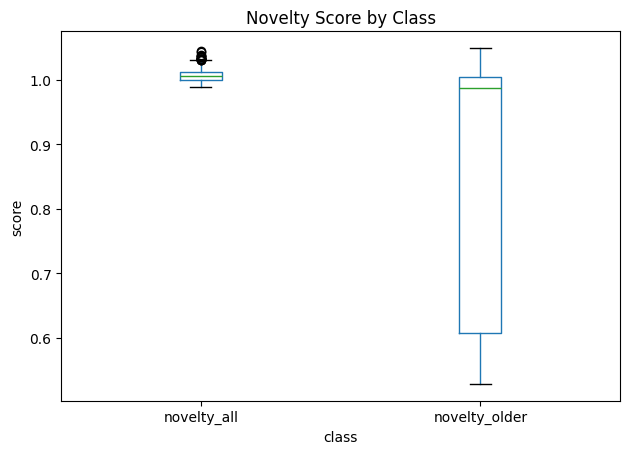

In [33]:
import matplotlib.pyplot as plt

plot_df = novelty_df[["novelty_all", "novelty_older"]].melt(
  var_name="class",
  value_name="score"
).dropna()

plt.figure(figsize=(7, 5))
plot_df.boxplot(column="score", by="class", grid=False)
plt.title("Novelty Score by Class")
plt.suptitle("")
plt.xlabel("class")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [34]:
def _mean_cosine_similarity(target_embedding, candidate_embeddings):
  if candidate_embeddings.size == 0:
    return None

  target_norm = np.linalg.norm(target_embedding)
  cand_norms = np.linalg.norm(candidate_embeddings, axis=1)

  denom = np.maximum(target_norm * cand_norms, 1e-12)
  sims = (candidate_embeddings @ target_embedding) / denom
  return float(np.mean(sims))


def compute_subset_avg_similarity_twice(subset_table, embedding_model="all-MiniLM-L6-v2"):
  rows = subset_table.to_pylist()
  papers = [_row_to_scoring_paper(row, i) for i, row in enumerate(rows)]

  if not papers:
    return pd.DataFrame()

  model = SentenceTransformer(embedding_model)
  paper_texts = [p["idea_text"] for p in papers]
  paper_embeddings = model.encode(
    paper_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
  )

  all_indices = list(range(len(papers)))
  results = []

  for target_idx, target in enumerate(papers):
    target_publish_date = target.get("publish_date")

    # Pool 1: all other papers
    all_pool = [i for i in all_indices if i != target_idx]
    sim_all = _mean_cosine_similarity(
      paper_embeddings[target_idx],
      paper_embeddings[all_pool] if all_pool else np.empty((0, paper_embeddings.shape[1])),
    )

    # Pool 2: papers at least 90 days older than target
    if target_publish_date is not None:
      cutoff = target_publish_date - timedelta(days=30)
      older_pool = [
        i
        for i, p in enumerate(papers)
        if i != target_idx
        and p.get("publish_date") is not None
        and p["publish_date"] <= cutoff
      ]
    else:
      older_pool = []

    sim_older = _mean_cosine_similarity(
      paper_embeddings[target_idx],
      paper_embeddings[older_pool] if older_pool else np.empty((0, paper_embeddings.shape[1])),
    )

    results.append(
      {
        "paperId": target["paperId"],
        "target_paper": target.get("title", ""),
        "target_publish_date": str(target_publish_date) if target_publish_date else None,
        "n_papers_all": len(all_pool),
        "n_papers_older": len(older_pool),
        "avg_cosine_similarity_all": sim_all,
        "avg_cosine_similarity_older": sim_older,
      }
    )

  return pd.DataFrame(results)


similarity_df = compute_subset_avg_similarity_twice(subset_table)
similarity_df.head(10)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6704.22it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 19/19 [00:25<00:00,  1.36s/it]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6704.22it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 19/19 [00:25<00:00,  1.36s/it]


,paperId,target_paper,target_publish_date,n_papers_all,n_papers_older,avg_cosine_similarity_all,avg_cosine_similarity_older
0,18,The topic of this paper is Human Pose and Shap...,2024-02-01,599,181,0.185213,0.179041
1,28,The topic of this paper is improving knowledge...,2024-03-01,599,181,0.275147,0.282988
2,33,The topic of this paper is improving long vide...,2024-04-01,599,282,0.376431,0.379298
3,94,The topic of this paper is Audio-Visual Speech...,2023-12-01,599,51,0.344059,0.371912
4,95,The topic of this paper is generating 3D model...,2024-06-01,599,362,0.282491,0.280342
5,290,The topic of this paper is mitigating atmosphe...,2024-05-01,599,315,0.172292,0.171215
6,314,The topic of this paper is 6D object pose esti...,2023-12-01,599,51,0.300339,0.304225
7,358,The topic of this paper is image-matching unce...,2024-03-01,599,181,0.195729,0.190533
8,420,The topic of this paper is reducing distributi...,2023-12-01,599,51,0.291961,0.319794
9,421,The topic of this paper is improving implicit ...,2024-02-01,599,181,0.246309,0.240104


<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

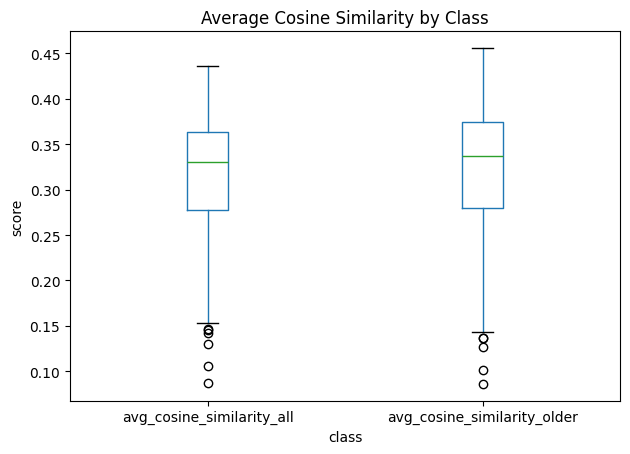

In [35]:
plot_df = similarity_df[["avg_cosine_similarity_all", "avg_cosine_similarity_older"]].melt(
  var_name="class",
  value_name="score"
).dropna()

plt.figure(figsize=(7, 5))
plot_df.boxplot(column="score", by="class", grid=False)
plt.title("Average Cosine Similarity by Class")
plt.suptitle("")
plt.xlabel("class")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [37]:
REFERENCE_DATE

datetime.datetime(2023, 10, 3, 0, 0)

In [38]:
# Load the original full table
full_table = pq.read_table(path)

# Extract all target paper titles
all_target_papers = full_table.column("target_paper").to_pylist()

print(f"Fetching publication dates for {len(all_target_papers)} papers...")

# Fetch publication dates for all papers
all_publish_dates = []
for i, title in enumerate(all_target_papers, start=1):
  all_publish_dates.append(fetch_publication_date(title))
  if i % 100 == 0:
    print(f"Processed {i}/{len(all_target_papers)}")
  time.sleep(0.12)

# Create a dataframe with titles and dates
dates_df = pd.DataFrame({
  "target_paper": all_target_papers,
  "publish_date": all_publish_dates
})

# Extract year from publish_date
dates_df["year"] = dates_df["publish_date"].apply(
  lambda x: int(x[:4]) if isinstance(x, str) and len(x) >= 4 else None
)

# Save to file
output_file = "./data/topic_data/all_papers_publish_dates.parquet"
dates_df.to_parquet(output_file, index=False)
print(f"Saved {len(dates_df)} papers with dates to: {output_file}")

# Plot count by year
year_counts = dates_df["year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
year_counts.plot(kind="bar")
plt.title("Paper Count by Publication Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()  
plt.show()

print("\nYear distribution:")
print(year_counts)

Fetching publication dates for 3495 papers...
Processed 100/3495
Processed 200/3495
Processed 300/3495
Processed 400/3495
Processed 500/3495
Processed 600/3495
Processed 700/3495
Processed 800/3495
Processed 900/3495
Processed 1000/3495
Processed 1100/3495
Processed 1200/3495
Processed 1300/3495
Processed 1400/3495
Processed 1500/3495
Processed 1600/3495
Processed 1700/3495
Processed 1800/3495


KeyboardInterrupt: 

In [44]:
all_publish_dates.__len__()

1861

In [45]:
all_target_papers[:1861]

['LangSplat 3D Language Gaussian Splatting',
 'PanoPose Self supervised Relative Pose Estimation for Panoramic Images',
 'LiveHPS LiDAR based Scene level Human Pose and Shape Estimation in Free Environment',
 'OneTracker Unifying Visual Object Tracking with Foundation Models and Efficient Tuning',
 'C2KD Bridging the Modality Gap for Cross Modal Knowledge Distillation',
 'Novel Class Discovery for Ultra Fine Grained Visual Categorization',
 'Logit Standardization in Knowledge Distillation',
 'SurroundSDF Implicit 3D Scene Understanding Based on Signed Distance Field',
 'Koala Key Frame Conditioned Long Video LLM',
 'From Feature to Gaze A Generalizable Replacement of Linear Layer for Gaze Estimation',
 'Image Neural Field Diffusion Models',
 'OpenESS Event based Semantic Scene Understanding with Open Vocabularies',
 'GAvatar Animatable 3D Gaussian Avatars with Implicit Mesh Learning',
 'AV2AV Direct Audio Visual Speech to Audio Visual Speech Translation with Unified Audio Visual Speech

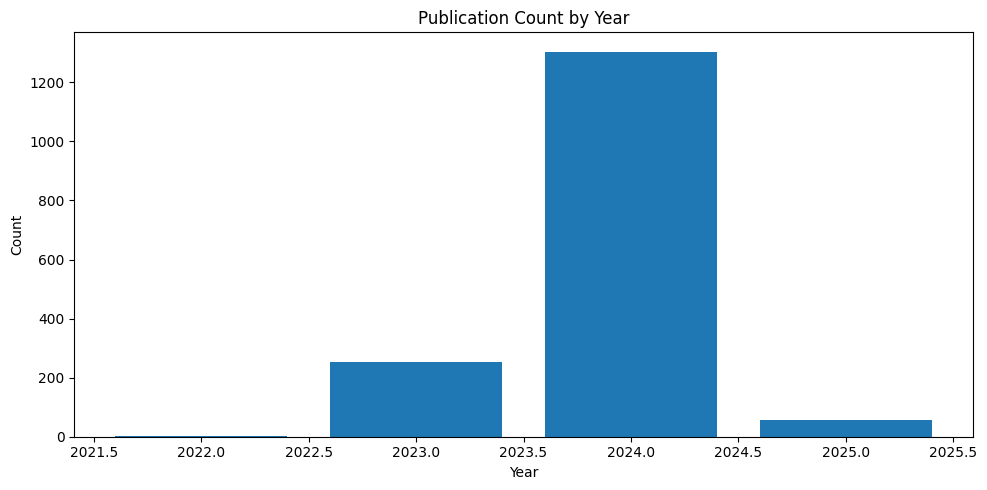

In [46]:
# Convert publish dates to years and count occurrences
years = pd.to_datetime(pd.Series(all_publish_dates), errors="coerce").dt.year
year_counts = years.dropna().astype(int).value_counts().sort_index()

# Plot: year (x) vs count (y)
plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Publication Count by Year")
plt.tight_layout()
plt.show()